# Fundamentals of Social Data Science 2025. Week 2. Day 3. Exercises

This is your individual assignment. 

You will be expected to submit an individual assignment on Monday at 12pm on Canvas. This will not be graded and only for record keeping. Thus, if you are not complete the assignment by that time, please submit your progress regardless.

> **NOTE 1:** This assignment will use data provided within the class. This assignment has NOT been cleared for research via the CUREC process. It is an in-class assignment. Therefore, if you wish to publish anything from this analysis, you must first apply for a CUREC before publishing anything publicly with your Oxford affiliation and you must collect novel data.

> **NOTE 2:** You will also be asked to write an _AI declaration_. We are not inhibiting your use of AI tools, but we need to understand how deeply these are entwined within your practice. 

# Q1. Merging networks 

The data on canvas is under "Network Canvas Export Tables.zip". If you extract this data file on your computer it should be a folder called "network_data", within which there will be a number of files (68, meaing 68/4=17 cases). They will be of the form: 

~~~
Anonymous Participant_cmh1trlci0002sa278d3vv3ip_attributeList_concept.csv
Anonymous Participant_cmh1trlci0002sa278d3vv3ip_edgeList_relate.csv
Anonymous Participant_cmh1trlci0002sa278d3vv3ip_ego.csv
Anonymous Participant_cmh1trlci0002sa278d3vv3ip.graphml
~~~

This is one file for the respondent, one for the list of alters, one for the connetions between alters. For this assignment you are welcome to process either the graphml or the CSVs. They should have the same data except the graphml has the data in a consolidated form. For the purposes of the assignment and the example answer we will be processing the CSV files in the example answer, however, you are welcome to use the graphml file, but this will either involve more complex text parsing or starting in `networkx`. 

From the $\approx 3 \times n$ files, please construct a single DataFrame at the alter level, `df_alter`. The resulting DataFrame should concatenate all the `attributeList` files and merge in data from the `ego` files as well as merge in data from the processed `edgeList` files. Why is it $n \approx 3$ and not $n = 3$? All cases should have an ego and alter files, but if someone did not submit any edges then the third file might not be present. 

The resulting DataFrame should have all of the columns from the `attribteList` and `ego` files. It should also have a column for 'is in giant component' `['in_gcc']`. 

> Note: This is not one row for each concept, but one row for each concept in each ego network.

> Check: The table should merge in the columns from the Ego table so that we have a column for `secret_word`, `networkCanvasEgoUUID`, and `networkCanvasSessionID`. (join)

> Check: The table should also have a column for the total number of alters for that ego. (aggregate)

> Check: For `in_gcc`: If there are two or more equally large components, indicate membership in _any_ of these components rather than just take the first one in the set. This will require you to create a network object for each ego, calculate which concepts are in the giant component and send that back to the main alter table. Thus, you will likely need to load the edgelist data into `networkx`, calculate the component structure, and use the membership within the components. If you are not sure, I would recommend holding off on this one until you have the others done. 

# Q1 Answer below here 

Please use markdown or python cells as necessary. 

In [3]:
# Part 1. Merging Ego and Alter Networks
 
import networkx as nx 
import pandas as pd 
from pathlib import Path

# Set the path to our files. For me it is under this folder in 
# "Network Canvas Export Tables"
file_path = Path.cwd() / "/Users/celikhanbaylan/Desktop/OII/FSDS/Network Canvas Export Tables"
file_list = file_path.glob(file_path / "*attributeList_concept.csv")

# The trickiest part is managing the linking key which comes from the file name
concept_files = [] 
for i in file_path.glob("*attributeList_concept.csv"):
    df_temp = pd.read_csv(i)
    session_id = i.name.split("_")[1]
    df_temp["session_id"] = session_id
    concept_files.append(df_temp)

# Concatenate all the alter files, then reset the index
df_alters = pd.concat(concept_files)
df_alters.reset_index()

# Now we explore the ego_files: 
# We can merge these directly where df_alter["session_id"] == ["networkCanvasSessionID"]
ego_files = []
for i in file_path.glob("*_ego.csv"):
    ego_files.append( pd.read_csv(i))

df_ego = pd.concat(ego_files)

df_alters = df_alters.merge(df_ego, left_on="session_id", right_on="networkCanvasSessionID")

# For a brief report, we can check the value_counts of the name variable
df_alters["name"].value_counts()

name
AI                 15
technology         11
empirical data     10
ethics             10
analysis           10
knowledge           9
context             8
theory              8
community           8
social networks     7
change              7
optimisation        6
perspective         6
truth               6
macro-micro         5
inequality          5
identity            5
culture             5
structure           5
power               4
development         4
policy              4
progress            4
social norms        3
justice             2
design              2
collective          2
user experience     2
class               2
privacy             2
race-ethnicity      2
art                 1
freedom             1
music               1
personal            1
history             1
individual          1
gender              1
Name: count, dtype: int64

In [4]:
# Part 2. Merging in Giant Component data
# This is considerably more challenging overall. 

# To attempt this, I first build a dictionary {"sessionID":file_path}
# I do this so later we know which path to merge with which session data.
edge_list = []
for i in file_path.glob("*ego.csv"):
    x = i.name.split("_")[:-1]
    x.append("edgeList_relate.csv")
    edge_path = Path(file_path / "_".join(x))
    key = i.name.split("_")[1]
    
    if edge_path.exists():
        edge_list.append(
            {"key":key,
             "path":edge_path
             })
    else:
        raise Exception("Warning: The edge path file does not exist.") 

# Now we can iterate through the paths. 
# For each path we create a network. I did this by:
# reading the CSV to a DataFrame
# taking the source and target columns as lists
# zipping the list: this way instead of [1,2,3,4], [a,b,c,d] we have [(1,a), (2,b), (3,c), (4,d)]
# a zip object is a 'generator' but we need it as list, so its list(zip(l1,l2))

edgelist_dfs = []
for edge_file in edge_list:
    edge_df = pd.read_csv(edge_file["path"])
    edges = zip(edge_df["networkCanvasSourceUUID"].to_list(),edge_df["networkCanvasTargetUUID"].to_list())
    edges = list(edges)
    G = nx.Graph(edges)
        
    # Once we have the zipped list, these are the edges. We can then check the giant component.
    ccs = sorted(list(nx.connected_components(G)), key=len, reverse=True)

    # Sort components to check if same length
    giant_component = ccs[0]
    if len(ccs) > 1:
        for i in ccs[1:]:
            if len(i) == len(ccs[0]):
                giant_component.extend(i)

    # Now we create a temporary dataframe with two columns: 
    # networkCanvasUUID (which is the ID of the concept)
    # networkCanvasSessionID (which is the joining key)
    df_temp = pd.DataFrame(giant_component, columns=["networkCanvasUUID"])
    df_temp["networkCanvasSessionID"] = edge_file["key"]
    # And we add "in_gcc" = 1, later we populate all the rest as 0
    df_temp["in_gcc"] = 1
    edgelist_dfs.append(df_temp)

# We concatenate all the components into a single DataFrame
# And then we use (and this is tricky as it was not mentioned in the lecture: )
df_edgelist_gcc = pd.concat(edgelist_dfs) 
df_alters = df_alters.merge(df_edgelist_gcc, on=["networkCanvasSessionID","networkCanvasUUID"], how="left")

# Where we didn't get a value from the merge, that node was not in the giant component for that ego
df_alters.fillna({"in_gcc":0}, inplace = True)

df_alters["in_gcc"].value_counts()

in_gcc
1.0    147
0.0     39
Name: count, dtype: int64

# Q2. Aggregating networks

Now with your `df_alter` DataFrame table, aggregate over the concepts to produce `df_concepts`, counting:
  - the number of times they appear 
  - the number of times they appear in the giant component

Q2.1: Descriptive questions: 
- How many concepts appear in total? 
- Which concept appears the most? Please produce a table ranking the concepts from most to least common. 

# Q2 Answer below here 

Please use markdown or python cells as necessary. 

In [5]:
# We filter first to the columns of interest: name and 'in_gcc'
# Then we groupby and get a count of these as well as a sum.
# Count will get us how many times the concept appeared; 
# Sum will get us how many times it appeared in the giant component.
df_concepts = df_alters[["name","in_gcc"]].groupby("name").agg(["count","sum"])
df_concepts.columns = ["concept_count", "concept_sum"]
df_concepts.sort_values("concept_count",ascending=False,inplace=True)
df_concepts

,concept_count,concept_sum
name,,
AI,15,12.0
technology,11,10.0
ethics,10,8.0
analysis,10,9.0
empirical data,10,9.0
knowledge,9,7.0
theory,8,7.0
community,8,6.0
context,8,7.0


# Q3. **Optional challenge questions: Distance metrics** 

This is optional as we have not yet gone through the measures of this, but for the intrepid student, you may want to do this on your own. We will cover these measures next week. 

## Q3.1. Euclidean distance.

Take the xy coordinates for each concept in the alter table. Calculate the distance from the center (should be [0.5, 0.5]). 
- For each concept in the alter_table: What is the distance from the center?
- For each concept in the concept_table: What is the mean distance from the center? What is the standard deviation?

Present a table with the $\approx 30$ concepts from least average distance to most average distance from the center.  

## Q3.2 Cosine similarity 

Calculate the angle around the circle. This should be in the form of a cosine rather than degree (e.g., 360 degrees). This would be per-ego. 

- For each concept in the alter_table: find the concept that is closest to this concept per network. Then merge this into the `df_concept` table such that the we know the concept that is most common as the closest to this concept. 
- For example, if on one network there is `identity` and the closest concept is `social networks` in one network, but `community` in three networks, then the `most_common_similar_concept` would be community. 
- For each concept in the `df_concept`: report the most common closest concept for each of the concepts in the network in a table. 




# Q3. answer below here

Please use markdown or python cells as necessary. 

,mentions,distance
name,,
design,2,0.081255
freedom,1,0.085239
history,1,0.103096
individual,1,0.107629
personal,1,0.109637
empirical data,10,0.111360
truth,6,0.129760
collective,2,0.131093
community,8,0.134687


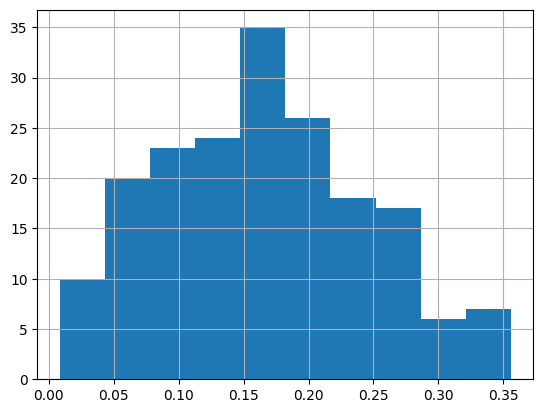

In [6]:
import numpy as np
# distance = np.linalg.norm([x - 0.5, y - 0.5])
# apply for rows rather than columns is axis=1
df_alters['distance'] = df_alters.apply(lambda row: np.linalg.norm([row['user_layout_x'] - 0.5, row['user_layout_y'] - 0.5]), axis=1)
df_alters["distance"].hist()

df_concepts_2 = df_alters[["name","distance"]].groupby("name").agg(["count","mean"])
df_concepts_2.columns = ["mentions","distance"]

# Sort the concepts so that least distance is on top.
df_concepts_2.sort_values("distance",inplace=True)
df_concepts_2

From the above analysis we can see that a few terms that were not mentioned often tended to be at the same time, the concepts most close to a given person. Thus when we look at the most common concepts, such as AI and ethics, these might not be the most important concepts for someone but a sort of key common concept. 

By visualising the distance as a histogram we can see that most of the nodes were around ring 2 or 3 (assuming that sqrt(2), being right in the corner, is the max distance, but rarely used).

In [7]:
# Note that in this section, ClaudeAI was used to calculate the cosine distance in radians.
# Code was integrated and edited 

import numpy as np
import pandas as pd

# This is because 330 and 30 degrees is really 60, not 300 degrees apart.
def angular_distance(angle1, angle2):
    """Calculate smallest angular distance between two angles (in radians)"""
    diff = np.abs(angle1 - angle2)
    return np.minimum(diff, 2*np.pi - diff)

# We are getting the angles within each egonet using 'group' (here 'group' is just a label)
def find_nearest_node_in_egonet(group):
    """Helper function to find nearest angle within a group"""
    angles = group['angle_rad'].values
    indices = group.index.values
    n = len(angles)
    
    # Just a sense check in case of a network with a single node
    if n <= 1:
        return pd.Series([None] * n, index=indices)
    
    # Create angular distance matrix
    # Notice the terms [:, None] and [None, :]
    angle_diff = np.abs(angles[:, None] - angles[None, :])
    angular_dist = np.minimum(angle_diff, 2*np.pi - angle_diff)
    
    # Set diagonal to infinity (default 0 would mean every term closest to itself)
    np.fill_diagonal(angular_dist, np.inf)
    
    # Get nearest index for each row
    # argmin means the minimum score within some vector
    nearest_positions = np.argmin(angular_dist, axis=1)
    nearest_indices = indices[nearest_positions]
    
    return pd.Series(nearest_indices, index=indices)

def find_nearest_node(df, category):
    """Vectorized version using groupby"""
    
    # Include groups is just for a future warning; we don't pass group structure, its unnecessary
    nearest_node = (df
                    .groupby(category, group_keys=False)
                    .apply(find_nearest_node_in_egonet,include_groups=False))
    return nearest_node.map(df_alters['name'])

# We first calculate the angle in radians for all alters independently. 
df_alters['angle_rad'] = np.arctan2(df_alters['user_layout_x'] - 0.5, df_alters['user_layout_y'] - 0.5)

# To get the nearest angle, we pass the DF as well as the grouping parameter
df_alters['nearest_angle_node'] = find_nearest_node(df_alters,"session_id")

# Now we create another concept network. 
df_concepts_3 = df_alters[["name","nearest_angle_node"]].groupby("name").agg(lambda x: x.mode()[0] if not x.mode().empty else None)

# We can concatenate these using axis=1 since we had the same idx (the concept name) for all our tables.
pd.concat([df_concepts, df_concepts_2, df_concepts_3],axis=1)


,concept_count,concept_sum,mentions,distance,nearest_angle_node
name,,,,,
AI,15,12.0,15,0.135176,ethics
technology,11,10.0,11,0.144910,development
ethics,10,8.0,10,0.148323,AI
analysis,10,9.0,10,0.144818,empirical data
empirical data,10,9.0,10,0.111360,technology
knowledge,9,7.0,9,0.154507,AI
theory,8,7.0,8,0.157885,AI
community,8,6.0,8,0.134687,identity
context,8,7.0,8,0.136123,AI


In [8]:

# -- config: column names used in your pipeline
CONCEPT = 'name'
ANGLE_COL = 'angle_rad'   # already computed by your code
MIN_APPEAR = 1            # drop concepts with fewer than this many appearances (optional)

# Make sure angle_rad exists; if not, compute it exactly as in your snippet:
if ANGLE_COL not in df_alters.columns:
    df_alters[ANGLE_COL] = np.arctan2(df_alters['user_layout_x'] - 0.5,
                                      df_alters['user_layout_y'] - 0.5)

# Drop rows with missing angle values
df_angles_work = df_alters[[CONCEPT, ANGLE_COL]].dropna(subset=[ANGLE_COL]).copy()
df_angles_work[ANGLE_COL] = df_angles_work[ANGLE_COL].astype(float)

# Function to compute circular mean & resultant length for an array of angles
def circular_stats(angles):
    """Return (n, mean_angle_rad, mean_angle_deg, resultant_length R in [0,1])."""
    angles = np.asarray(angles, dtype=float)
    n = angles.size
    if n == 0:
        return 0, np.nan, np.nan, np.nan
    mean_sin = np.mean(np.sin(angles))
    mean_cos = np.mean(np.cos(angles))
    mean_angle = np.arctan2(mean_sin, mean_cos)           # circular mean in radians
    mean_angle_deg = np.degrees(mean_angle)              # easier to read
    R = np.sqrt(mean_sin**2 + mean_cos**2)               # resultant length (concentration)
    return n, mean_angle, mean_angle_deg, R

# Group by concept and compute circular stats
rows = []
for concept, g in df_angles_work.groupby(CONCEPT, sort=True):
    n, mean_angle_rad, mean_angle_deg, R = circular_stats(g[ANGLE_COL].values)
    if n < MIN_APPEAR:
        continue
    rows.append({
        CONCEPT: concept,
        'n_appearances': int(n),
        'mean_angle_rad': float(mean_angle_rad),
        'mean_angle_deg': float(mean_angle_deg),
        'resultant_length': float(R)   # R near 1 -> tight clustering in angle; near 0 -> scattered
    })

df_concept_angles = pd.DataFrame(rows).sort_values('n_appearances', ascending=False).reset_index(drop=True)

# Example: merge into df_concepts_3 (if you want to add the mean angle to that table)
# If df_concepts_3 has concept names as its index, reset index first:
try:
    df_c3 = df_concepts_3.reset_index().rename(columns={'index':'name'})
except Exception:
    df_c3 = df_concepts_3.copy()
if 'name' not in df_c3.columns:
    # ensure we have a name column to merge on
    df_c3 = df_c3.reset_index().rename(columns={'index':'name'})

df_concepts_3_with_angle = df_c3.merge(df_concept_angles, how='left', left_on='name', right_on=CONCEPT)

# show results
print("Top concept angles (sample):")
print(df_concept_angles.head(20))


Top concept angles (sample):
               name  n_appearances  mean_angle_rad  mean_angle_deg  \
0                AI             15       -0.800271      -45.852166   
1        technology             11        1.267379       72.615470   
2            ethics             10       -2.118975     -121.408337   
3          analysis             10        0.544262       31.183889   
4    empirical data             10        0.053661        3.074564   
5         knowledge              9        3.134290      179.581568   
6            theory              8       -2.435200     -139.526703   
7         community              8        0.819185       46.935831   
8           context              8        3.039041      174.124215   
9            change              7       -2.561847     -146.783014   
10  social networks              7        0.627213       35.936648   
11     optimisation              6        2.236978      128.169407   
12      perspective              6       -1.749452     -100.2

In [9]:
df_concept_angles.set_index('name', inplace=True)

# Check it worked
print(df_concept_angles.head())

# Now you can concat easily with the earlier DataFrames
df_concepts_all = pd.concat([df_concepts, df_concepts_2, df_concepts_3, df_concept_angles], axis=1)

# Optional: inspect or save
print(df_concepts_all.head())
df_concepts_all.to_csv("concepts_summary_all.csv")

                n_appearances  mean_angle_rad  mean_angle_deg  \
name                                                            
AI                         15       -0.800271      -45.852166   
technology                 11        1.267379       72.615470   
ethics                     10       -2.118975     -121.408337   
analysis                   10        0.544262       31.183889   
empirical data             10        0.053661        3.074564   

                resultant_length  
name                              
AI                      0.343651  
technology              0.076702  
ethics                  0.348042  
analysis                0.174442  
empirical data          0.358148  
                concept_count  concept_sum  mentions  distance  \
name                                                             
AI                         15         12.0        15  0.135176   
technology                 11         10.0        11  0.144910   
ethics                     10      

In [10]:
df_concept_angles

,n_appearances,mean_angle_rad,mean_angle_deg,resultant_length
name,,,,
AI,15,-0.800271,-45.852166,0.343651
technology,11,1.267379,72.615470,0.076702
ethics,10,-2.118975,-121.408337,0.348042
analysis,10,0.544262,31.183889,0.174442
empirical data,10,0.053661,3.074564,0.358148
knowledge,9,3.134290,179.581568,0.535364
theory,8,-2.435200,-139.526703,0.140588
community,8,0.819185,46.935831,0.252744
context,8,3.039041,174.124215,0.332215


In [11]:
df_concepts_all

,concept_count,concept_sum,mentions,distance,nearest_angle_node,n_appearances,mean_angle_rad,mean_angle_deg,resultant_length
name,,,,,,,,,
AI,15,12.0,15,0.135176,ethics,15,-0.800271,-45.852166,0.343651
technology,11,10.0,11,0.144910,development,11,1.267379,72.615470,0.076702
ethics,10,8.0,10,0.148323,AI,10,-2.118975,-121.408337,0.348042
analysis,10,9.0,10,0.144818,empirical data,10,0.544262,31.183889,0.174442
empirical data,10,9.0,10,0.111360,technology,10,0.053661,3.074564,0.358148
knowledge,9,7.0,9,0.154507,AI,9,3.134290,179.581568,0.535364
theory,8,7.0,8,0.157885,AI,8,-2.435200,-139.526703,0.140588
community,8,6.0,8,0.134687,identity,8,0.819185,46.935831,0.252744
context,8,7.0,8,0.136123,AI,8,3.039041,174.124215,0.332215


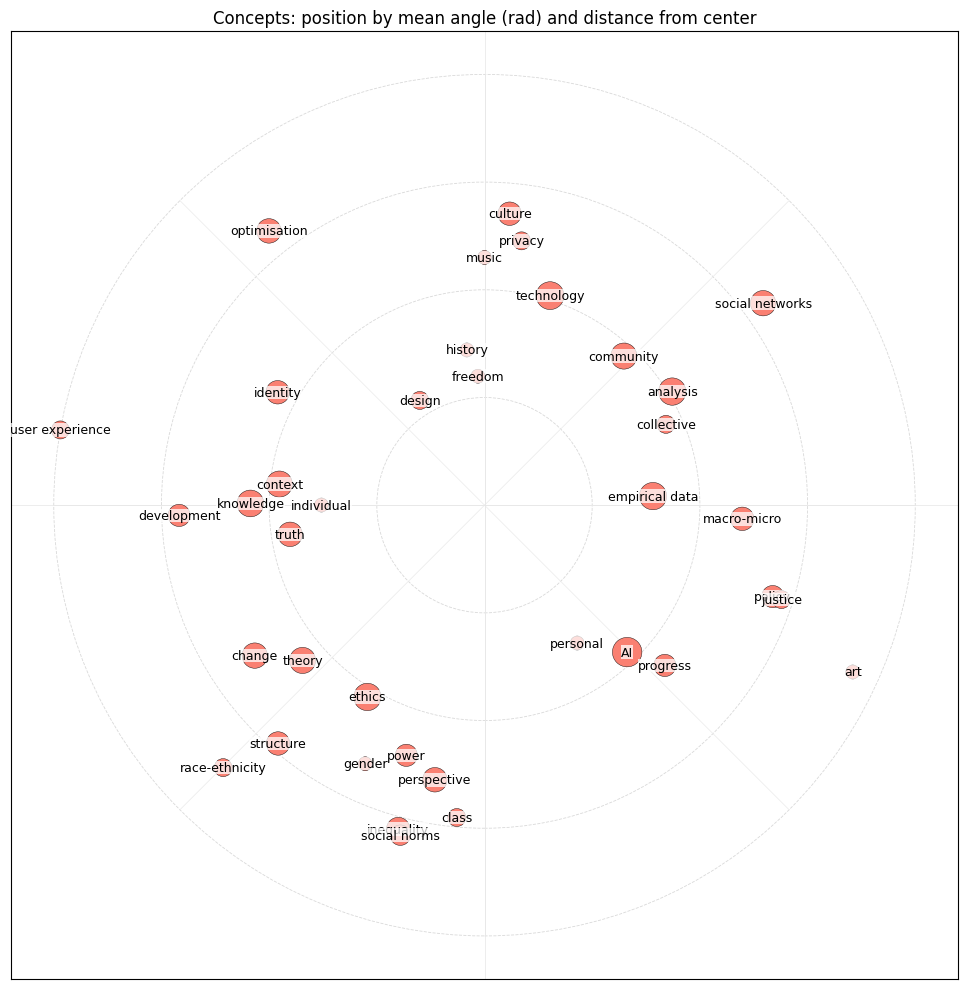

Plotted 38 concepts. Saved to concepts_circular_map.png


In [12]:
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
DF = df_concepts_all            # your final dataframe, indexed by concept name
ANGLE_COL = 'mean_angle_rad'    # radians
DIST_COL = 'distance'           # euclidean distance from center (already computed)
FREQ_COL = 'concept_count'
#RESULTANT_COL = 'resultant_length'   # optional: concentration of angles (0..1)
FIGSIZE = (10,10)
SAVE_PATH = 'concepts_circular_map.png'
GUIDE_CIRCLES = True
MAX_LABELS = None   # None = label all; or set int to label top-N by frequency
# -----------------------------

# --- Basic checks ---
if ANGLE_COL not in DF.columns and ANGLE_COL not in DF.index:
    raise KeyError(f"Angle column '{ANGLE_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")
if DIST_COL not in DF.columns:
    raise KeyError(f"Distance column '{DIST_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")

# ensure index is name
df = DF.copy()
if df.index.name != 'name' and 'name' in df.columns:
    df = df.set_index('name')

# select and drop missing rows
cols_needed = [ANGLE_COL, DIST_COL]
df_plot = df[cols_needed + [c for c in ([FREQ_COL]) if c in df.columns]].copy()
df_plot = df_plot.dropna(subset=[ANGLE_COL, DIST_COL])

# extract plotting arrays
thetas = df_plot[ANGLE_COL].astype(float).values   # radians
rs     = df_plot[DIST_COL].astype(float).values

# polar -> cartesian (center at 0,0)
xs = rs * np.cos(thetas)
ys = rs * np.sin(thetas)
df_plot['_x'] = xs
df_plot['_y'] = ys


# marker sizes based on log(concept_count)
if 'concept_count' not in df_plot.columns:
    raise KeyError("'concept_count' column not found in df_concepts_all.")

# compute log-scaled sizes (add 1 to avoid log(0))
freq = np.log1p(df_plot['concept_count'].astype(float))

# normalize to a visual range (e.g., 40–420)
s_min, s_max = 100, 450
if freq.max() == freq.min():
    sizes = np.full_like(freq, (s_min + s_max) / 2)
else:
    sizes = s_min + (freq - freq.min()) / (freq.max() - freq.min()) * (s_max - s_min)

"""# marker sizes: scale by best available freq column or constant
freq_col = next((c for c in FREQ_COL if c in df_plot.columns), None)
if freq_col:
    freq = df_plot[freq_col].astype(float).fillna(0)
    s_min, s_max = 40, 420
    if freq.max() == freq.min():
        sizes = np.full_like(freq, (s_min+s_max)/2)
    else:
        sizes = s_min + (freq - freq.min())/(freq.max()-freq.min())*(s_max-s_min)
else:
    sizes = np.full(len(df_plot), 120)"""

# Use one color for all nodes
colors = 'salmon'      # or any Matplotlib color name, e.g. 'gray', 'crimson', '#1f77b4'
colorbar_label = None     # no colorbar needed

"""# colors: use resultant_length if present else single color
if RESULTANT_COL in df_plot.columns:
    vals = df_plot[RESULTANT_COL].astype(float).fillna(0)
    cmap = plt.get_cmap('viridis')
    normed = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    colors = cmap(normed)
    colorbar_label = 'resultant_length (angle concentration)'
else:
    colors = 'C0'
    colorbar_label = None"""

# choose labels (optionally top-N by freq)
if MAX_LABELS and freq_col:
    label_idx = df_plot.sort_values(freq_col, ascending=False).head(MAX_LABELS).index
elif MAX_LABELS:
    label_idx = df_plot.index[:MAX_LABELS]
else:
    label_idx = df_plot.index

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect('equal')

# scatter nodes
scatter = ax.scatter(df_plot['_x'], df_plot['_y'], s=sizes, c=colors, edgecolor='k', linewidth=0.3, zorder=3)

# guide circles and radial lines
if GUIDE_CIRCLES:
    max_r = np.nanmax(rs) if len(rs)>0 else 1.0
    circles = np.linspace(0, max_r, 5)[1:]
    for r in circles:
        ax.add_artist(plt.Circle((0,0), r, color='0.85', fill=False, linestyle='--', linewidth=0.6, zorder=0))
    for deg in range(0, 360, 45):
        theta = np.deg2rad(deg)
        ax.plot([0, max_r*np.cos(theta)], [0, max_r*np.sin(theta)], color='0.93', linewidth=0.6, zorder=0)

# labels
for name in label_idx:
    row = df_plot.loc[name]
    ax.text(row['_x'], row['_y'], str(name), fontsize=9, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=0.2), zorder=4)

# optional colorbar
if colorbar_label:
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

# cosmetics (center intentionally left empty)
ax.axhline(0, color='0.9', linewidth=0.5)
ax.axvline(0, color='0.9', linewidth=0.5)
ax.set_title('Concepts: position by mean angle (rad) and distance from center')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print(f"Plotted {len(df_plot)} concepts. Saved to {SAVE_PATH}")
